# <center> Exploratory data analysis on Russian job market.

### <center> Dataset from hh.ru

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Exploring data structure

In [11]:
dst= pd.read_csv('data/dst-3.0_16_1_hh_database.csv', sep=';')

In [12]:
dst.head()

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано
3,"Мужчина , 38 лет , родился 25 июня 1980",100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"Саратов , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,OpenSoft,Инженер-программист,Высшее образование 2002 Саратовский государст...,08.04.2019 14:23,Не указано
4,"Женщина , 26 лет , родилась 3 марта 1993",140000 руб.,Региональный менеджер по продажам,"Москва , не готова к переезду , готова к коман...",полная занятость,полный день,Опыт работы 5 лет 7 месяцев Региональный мене...,Мармелад,Менеджер по продажам,Высшее образование 2015 Кгу Психологии и педаг...,22.04.2019 10:32,Не указано


In [13]:
dst.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

There are missing values in several columns. 

In [14]:
dst.describe()

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 1987 Военный инженерный Кра...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


# Feature engeneering

In [15]:
#Function for geting degree categories
def get_degrees(text):
    text = text.lower()
    if text.startswith('высшее'):
        return 'высшее'
    elif text.startswith('неоконченное высшее'):
        return 'неоконченное высшее'
    elif text.startswith('среднее специальное'):
        return 'среднее специальное'
    elif text.startswith('среднее'):
        return 'среднее'

#Applying function and driping orisinal columns   
dst['Образование'] = dst['Образование и ВУЗ'].apply(get_degrees)
dst['Образование'] = dst['Образование'].astype('category')
dst = dst.drop('Образование и ВУЗ', axis=1)
dst['Образование'].value_counts()

Образование
высшее                 33863
среднее специальное     5765
неоконченное высшее     4557
среднее                  559
Name: count, dtype: int64

After categorizing degrees we can see that most people have bachelors degee.

In [ ]:
#Using lambda function to categorise gender
dst['Пол'] = dst['Пол, возраст'].apply(lambda x: 'М' if 'Мужчина' in x else 'Ж')
dst['Пол'] = dst['Пол'].astype('category')

#Function for getting age.
def get_age(text):
    text = text.split(',')
    r = text[1]
    return int(r[1:4])

dst['Возраст'] = dst['Пол, возраст'].apply(get_age)
dst['Возраст'].mean()
dst = dst.drop('Пол, возраст', axis=1)

In [ ]:
#Function for getting experience in months.
def get_exp(text):
    if text is np.nan or text == 'Не указано':
        return np.nan
    text = text.split()
    years = ['год', 'года', 'лет']
    months = ['месяц', 'месяца', 'месяцев']
    result_y=0
    result_m=0
    for y in years:
        if y in text[2:4]:
                index_y = text.index(y)
                result_y = int(text[index_y-1])
    for m in months:
        if m in text[4:6]:
            index_m = text.index(m)
            result_m = int(text[index_m-1])
    result= result_y*12 + result_m
    return int(result)
            
dst['Опыт работы (месяц)'] = dst['Опыт работы'].apply(get_exp)
dst = dst.drop('Опыт работы', axis=1)
dst['Опыт работы (месяц)'].median()

100.0

In [ ]:
#Function for cities
def get_city(text):
    million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород', 'Казань', 'Челябинск', 'Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж', 'Волгоград' ]
    text = text.split(',')
    if 'Москва' in text[0]:
        return 'Москва'
    elif 'Санкт-Петербург' in text[0]:
        return 'Санкт-Петербург'
    for city in million_cities:
        if city in text[0]:
            return 'город-миллионник'
    else:
        return 'другие'

dst['Город'] = dst['Город, переезд, командировки'].apply(get_city)
dst['Город'] = dst['Город'].astype('category')
#dst['Город'].value_counts(normalize=True)
#Function for getting is the person ready for relocation
def get_relocation(text):
    text = text.split(',')
    if 'не' in text[1] or 'не' in text[2]:
        return False
    else:
        return True

dst['Готовность к переезду'] = dst['Город, переезд, командировки'].apply(get_relocation)
#Function for getting is the person ready for work trip.
def get_work_trip(text):
    text = text.split(',')
    if 'командировкам' in text[-1]:
        if 'не' not in text[-1]:
            return True
        else:
            return False
    else:
        return False
    
dst['Готовность к командировкам'] = dst['Город, переезд, командировки'].apply(get_work_trip)
dst = dst.drop('Город, переезд, командировки', axis=1)
dst[['Готовность к командировкам', 'Готовность к переезду']].value_counts(normalize=True)

Готовность к командировкам  Готовность к переезду
True                        False                    0.392835
                            True                     0.314299
False                       False                    0.281021
                            True                     0.011845
Name: proportion, dtype: float64

In [ ]:
#Getting dummies, becouse for some reason pd.get_dummies didnt work
dst['полная занятость'] = dst['Занятость'].apply(lambda x: True if 'полная занятость' in x else False)
dst['частичная занятость'] = dst['Занятость'].apply(lambda x: True if 'частичная занятость' in x else False)
dst['проектная работа'] = dst['Занятость'].apply(lambda x: True if 'проектная работа' in x else False)
dst['волонтерство'] = dst['Занятость'].apply(lambda x: True if 'волонтерство' in x else False)
dst['стажировка'] = dst['Занятость'].apply(lambda x: True if 'стажировка' in x else False)
dst['полный день'] = dst['График'].apply(lambda x: True if 'полный день' in x else False)
dst['сменный график'] = dst['График'].apply(lambda x: True if 'сменный график' in x else False)
dst['гибкий график'] = dst['График'].apply(lambda x: True if 'гибкий график' in x else False)
dst['удаленная работа'] = dst['График'].apply(lambda x: True if 'удаленная работа' in x else False)
dst['вахтовый метод'] = dst['График'].apply(lambda x: True if 'вахтовый метод' in x else False)
table1 = dst.groupby(['проектная работа', 'волонтерство']).size()
table2 = dst.groupby(['вахтовый метод', 'гибкий график']).size()
dst = dst.drop(['Занятость','График'], axis=1)
display(table1, table2)

проектная работа  волонтерство
False             False           36626
                  True               50
True              False            7632
                  True              436
dtype: int64

вахтовый метод  гибкий график
False           False            28387
                True             13273
True            False              773
                True              2311
dtype: int64

In [ ]:
#Readin exchange rate file and converting all espected salaries to russian ruble.
exchange_rates = pd.read_csv('data/ExchangeRates.csv', sep=',')
dst['Обновление резюме'] = pd.to_datetime(dst['Обновление резюме'], dayfirst= True)
exchange_rates['date'] = pd.to_datetime(exchange_rates['date'], dayfirst=False)
dst['Обновление резюме'] = dst['Обновление резюме'].dt.date
exchange_rates['date'] = exchange_rates['date'].dt.date
dst['number'] = dst['ЗП'].apply(lambda x: x.split()[0])
dst['number'] = dst['number'].astype(int)
dst['curr'] = dst['ЗП'].apply(lambda x: x.split()[1])
dst['curr'] = dst['curr'].apply(lambda x: x.replace('.',''))
#Making dict with ISO codes.
curr = {
    'грн':'UAH',
    'белруб':'BYN',
    'сум':'UZS',
    'руб':'RUB',
    'USD': 'USD', 
    'KZT': 'KZT',
    'EUR': 'EUR', 
    'KGS': 'KGS',
    'AZN': 'AZN'
}
#Changing currencies and merging two tables
dst['curr']= dst['curr'].apply(lambda x: curr[x])

new_dst = dst.merge(
    exchange_rates[['date','currency','close','proportion']],
    left_on=['Обновление резюме','curr'],
    right_on=['date','currency'],
    how='left'
)
new_dst['close'] = new_dst['close'].fillna(1)
new_dst['proportion'] = new_dst['proportion'].fillna(1)
new_dst['ЗП (руб)'] = new_dst['number']*new_dst['close']/new_dst['proportion']
new_dst = new_dst.drop(['date','ЗП','curr', 'number', 'proportion', 'close','currency'], axis=1)
new_dst['ЗП (руб)'].median()

C:\Users\alber\AppData\Local\Temp\ipykernel_30168\1823353997.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  exchange_rates['date'] = pd.to_datetime(exchange_rates['date'], dayfirst=False)


59000.0

# Findig dependecies in data

Text(0.5, 1.0, 'Age distribution')

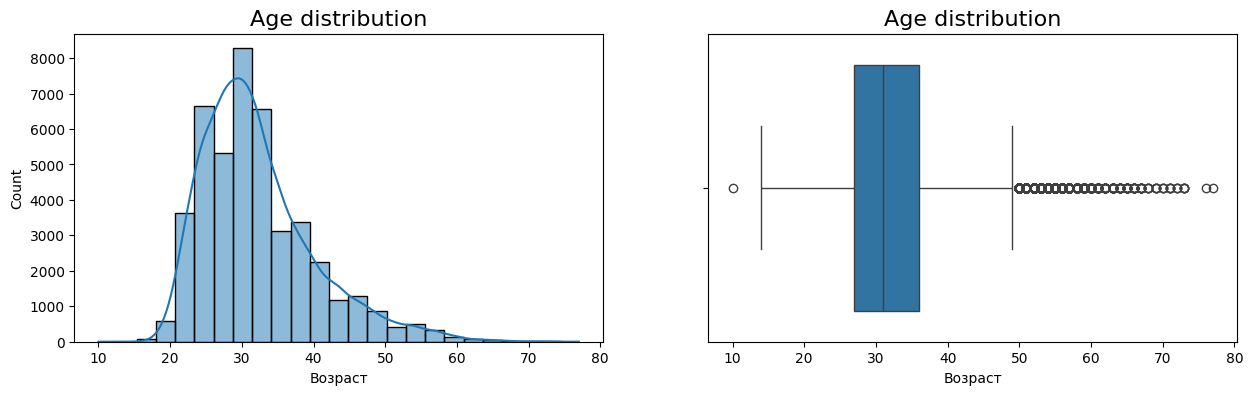

In [41]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))

sns.histplot(
    data=new_dst,
    x='Возраст',
    bins=25,
    kde=True,
    ax=axes[0]
);
axes[0].set_title('Age distribution', fontsize=16)
axes[0].set_ylabel('Count')

sns.boxplot(
    data=new_dst,
    x='Возраст',
    ax=axes[1]
)

axes[1].set_title('Age distribution', fontsize=16)

This histogram shows that most applicants are between 20 and 40 years old, with the most common candidate being around 30. The boxplot shows that the data contains many outliers and anomalies. It's also worth noting that the graph is not symmetrical and skews to the right.

In [39]:
fig = px.histogram(
    data_frame=new_dst,
    x='Опыт работы (месяц)',
    title='Experience in month distributton',
    marginal='box',
    nbins=50 
)
fig.write_html(r'C:\Users\alber\Desktop\EDA_CV_HH\graphs\exp.html')
fig.show()

This graph is similar in shape to the previous one, which is expected since there is a correlation between these characteristics. Here, the largest number of applicants have work experience ranging from 0 to 200 months, with a peak between 50 and 100 months. The data for this graph is unclear and contains anomalies. One applicant has 1,188 months of experience, which is unlikely.

In [40]:
fig= px.histogram(
    data_frame=new_dst,
    x='ЗП (руб)',
    title='Expected salary distribution',
    marginal='box',
)
fig.write_html(r'C:\Users\alber\Desktop\EDA_CV_HH\graphs\zp.html')
fig.show()

It is impossible to draw conclusions from this graph because the data contains too many outliers. The mode for this graph is from 47,500 rubles to 52,490 rubles.

In [42]:
ms= new_dst[new_dst['ЗП (руб)'] < 1000000]
median_salary= ms.groupby('Образование', as_index=False)['ЗП (руб)'].median()
fig = px.bar(
    data_frame=median_salary,
    x="Образование", 
    y="ЗП (руб)",
    color='Образование',
    text = 'ЗП (руб)', 
    orientation='v', 
    height=500, 
    width=1000, 
    title='Diagram of dependency of median expected salary to a degree.'
)
fig.write_html(r'C:\Users\alber\Desktop\EDA_CV_HH\graphs\degrees_zp.html')
fig.show()

C:\Users\alber\AppData\Local\Temp\ipykernel_30168\772042182.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



The diagram shows the impact of education on desired salary. Job seekers with higher education have the highest salary expectations. It's also interesting that people with secondary and vocational education expect similar salary levels. Obtaining a higher education still provides a significant career boost.

In [43]:
fig = px.box(
    data_frame= ms,
    x= 'ЗП (руб)',
    y= 'Город',
    color='Город',
    title='Boxplot of dependency of expected salary to city.'
)
fig.write_html(r'C:\Users\alber\Desktop\EDA_CV_HH\graphs\city_zp.html')
fig.show()

This boxplot shows the impact of location on desired salary. As expected, salaries in Moscow are generally higher than in other cities. It's also important to note that there's little difference between salaries in cities with a population of over a million and in other Russian cities. Presumably, if someone isn't from Moscow or St. Petersburg, there won't be much of a difference in desired salary.

In [44]:
bar_dst = new_dst.groupby(
    ['Готовность к командировкам', 'Готовность к переезду'],
    as_index=False
)['ЗП (руб)'].median()
fig = px.bar(
    data_frame=bar_dst,
    y='Готовность к переезду',
    x='ЗП (руб)',
    barmode="group",
    color='Готовность к командировкам',
    title='Median expected salary to ability to relocate'
)
fig.write_html(r'C:\Users\alber\Desktop\EDA_CV_HH\graphs\move_trip_zp.html')
fig.show()

Here we look at how willingness to relocate and travel affects desired salary. Job seekers who consider the ability to both  relocate and travel are the most valuable asset. Interestingly, willingness to travel is valued more than willingness to relocate.

C:\Users\alber\AppData\Local\Temp\ipykernel_30168\1873292653.py:1: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



Text(0.5, 1.0, 'Тепловая карта зп в зависимости от образования и возраста')

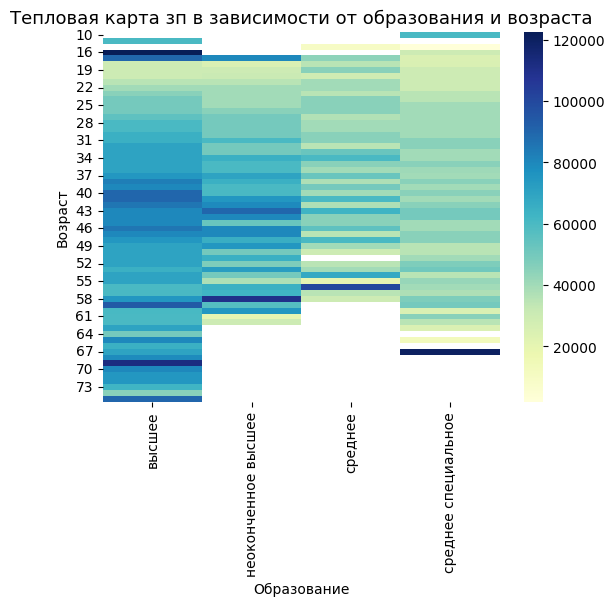

In [ ]:
table_dst = new_dst.pivot_table(
    values='ЗП (руб)',
    index='Возраст',
    columns='Образование',
    aggfunc='median'
)
heatmap = sns.heatmap(data=table_dst, cmap='YlGnBu')
heatmap.set_title('Heatmap of expected salaries in dependency of a degree and age', fontsize=13)

This heat map shows us how much higher education translates into a more long-term career. Interestingly, people with only a secondary vocational education continue to look for work later in life, although they are willing to be paid less.

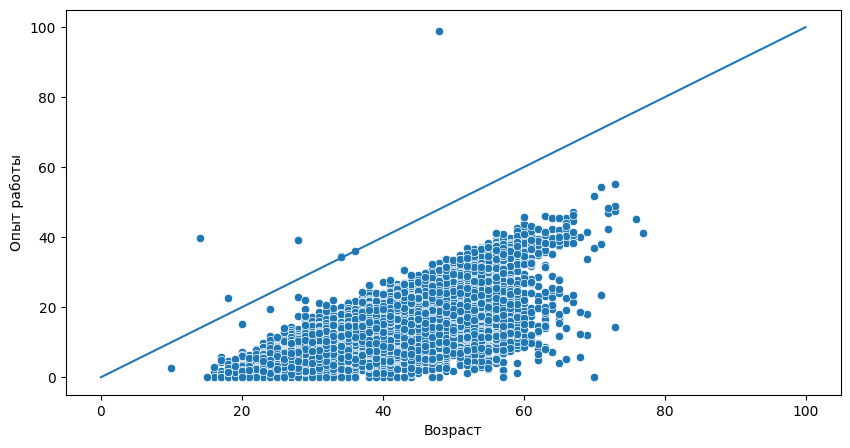

In [28]:
scatter_table= new_dst.copy()
scatter_table['Опыт работы'] = scatter_table['Опыт работы (месяц)']/12
fig = plt.figure(figsize=(10, 5))
sns.lineplot(x=[0, 100], y=[0, 100])
ax = sns.scatterplot(
    data=scatter_table, 
    x='Возраст',
    y='Опыт работы',
)

This scatterplot helps us see the distribution of experience and age, and also allows us to identify outliers in the data thanks to the line drawn.

In [45]:
line_dst = new_dst.groupby('Обновление резюме', as_index=False)['удаленная работа'].sum()
fig = px.line( data_frame=line_dst, 
    x='Обновление резюме', 
    y=['удаленная работа'], 
    height=500, 
    width=1000, 
    title='The increase of remote roles'
)
fig.write_html(r'C:\Users\alber\Desktop\EDA_CV_HH\graphs\remote_jobs.html')
fig.show()

In [46]:
gender_table= new_dst.groupby(['Пол', 'гибкий график'], as_index=False)['ЗП (руб)'].median()
fig = px.bar(
    data_frame=gender_table,
    y='Пол',
    x='ЗП (руб)',
    barmode="group",
    color='гибкий график',
    title='Median salary for men and women in full-time employment')
fig.write_html(r'C:\Users\alber\Desktop\EDA_CV_HH\graphs\gender_zp.html')
fig.show()

C:\Users\alber\AppData\Local\Temp\ipykernel_30168\967237520.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



I created this graph to see how expected salary changes depending on gender and work schedule. For men, the desired salary remains unchanged. But for women, when flexible work schedules are specified, the salary is 10,000 rubles lower.

# Data cleaning

In [31]:
dupl_columns = list(new_dst.columns)

mask = new_dst.duplicated(subset=dupl_columns)
dst_duplicates = new_dst[mask]
dst_deduped = new_dst.drop_duplicates(subset=dupl_columns)
display(dst_duplicates.shape[0])

161

In [32]:
dst_null= dst_deduped.isnull().sum()
display(dst_null[dst_null>0].sort_values(ascending=False))

Опыт работы (месяц)                168
Последняя/нынешняя должность         2
Последнее/нынешнее место работы      1
dtype: int64

In [33]:
m = dst_deduped.shape[1]
dst_drop = dst_deduped.dropna(thresh=m-1, axis=0)
dst_drop['Опыт работы (месяц)'] = dst_drop['Опыт работы (месяц)'].fillna(dst_drop['Опыт работы (месяц)'].median())
dst_drop['Опыт работы (месяц)'].mean()

C:\Users\alber\AppData\Local\Temp\ipykernel_30168\1638095084.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



114.12419810685927

In [34]:
unreal_zp = dst_drop[(dst_drop['ЗП (руб)'] > 1000000) | (dst_drop['ЗП (руб)'] < 1000)]
dst_drop = dst_drop.drop(unreal_zp.index)
unreal_zp.shape[0]

89

In [35]:
unreal_exp = dst_drop[dst_drop['Опыт работы (месяц)']/12 >=dst_drop['Возраст']]
dst_drop = dst_drop.drop(unreal_exp.index)
unreal_exp.shape[0]

7

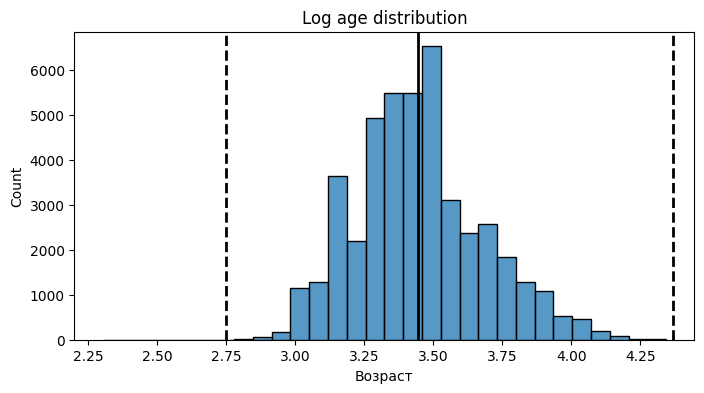

In [48]:
def outliers_z_score_mod(data, feature, log_scale=True, left=3, right=4):
    if log_scale:
        x = np.log(data[feature])
    else:
        x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - left * sigma
    upper_bound = mu + right * sigma
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
log_age = np.log(dst_drop['Возраст'] )
histplot = sns.histplot(log_age, bins=30, ax=ax)
histplot.axvline(log_age.mean(), color='k', lw=2)
histplot.axvline(log_age.mean()+ 4 * log_age.std(), color='k', ls='--', lw=2)
histplot.axvline(log_age.mean()- 3 * log_age.std(), color='k', ls='--', lw=2)
histplot.set_title('Log age distribution');

In [37]:
outliers, cleaned = outliers_z_score_mod(dst_drop, 'Возраст', log_scale=True)
outliers.head()

,Ищет работу на должность:,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Образование,Пол,Возраст,Опыт работы (месяц),Город,...,частичная занятость,проектная работа,волонтерство,стажировка,полный день,сменный график,гибкий график,удаленная работа,вахтовый метод,ЗП (руб)
31137,Менеджер по работе с клиентами,"ООО ""ФёрстКэшКомпани""",Менеджер по работе с клиентами,2019-04-06,Не указано,среднее,М,15,0.0,Санкт-Петербург,...,True,False,False,False,False,True,True,True,False,10000.0
32950,Тестировщик игр,OOO ЖМЫХ,Тестировщик ПО,2019-04-09,Не указано,среднее специальное,М,15,0.0,другие,...,False,False,False,False,True,False,False,False,False,2000.0
33654,Frontend-разработчик,Freelance,Frontend-разработчик,2019-04-19,Не указано,среднее специальное,М,10,30.0,Санкт-Петербург,...,True,True,False,True,True,False,True,True,False,60000.0
